# 도메인 광고 운영 전략

도메인별 광고유형 성과, 집행 규모, 이탈 유형 연결
전략 우선유형과 운영 리스크 분리 확인


## 0. 기본 설정

라이브러리, 출력 설정, 한글 폰트


In [1]:
# 라이브러리
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency


# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', '{:,.2f}'.format)
# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font='Malgun Gothic', rc={'axes.unicode_minus': False})


c:\Users\ckcma\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1. 데이터 로드

광고 목록, 전환 로그, 클릭 로그 기준 데이터 확인
분석용 도메인/광고유형/단가구간 정리


In [2]:
# CSV 로드 ([광고목록], [광고참여정보], [광고적립])
df_master = pd.read_csv('../domain_master_analysis_compact.csv', encoding='utf-8-sig')
df_engagement = pd.read_csv(
    '../result_260322_2000/cleaned_engagement_data.csv',
    encoding='utf-8-sig',
    usecols=['ads_idx', 'click_key', 'click_date'],
    dtype={
        'ads_idx': 'int32',
        'click_key': 'object',
        'click_date': 'object'
    }
)
df_reward = pd.read_csv(
    '../result_260322_2000/cleaned_reward_data.csv',
    encoding='utf-8-sig',
    usecols=['ads_idx', 'click_key', 'adv_cost', 'click_date'],
    dtype={'ads_idx': 'int32', 'click_key': 'object', 'click_date': 'object'}
)

# 도메인 유형
domain_map = {1: '엔터', 2: '금융', 3: '라이프', 4: '커머스', 5: '기타'} 

# 광고 유형
type_map = {
    1: '설치형', 2: '실행형', 3: '참여형', 4: '클릭형',
    5: '페이스북', 6: '트위터', 7: '인스타그램',
    9: '퀘스트', 10: '유튜브', 11: '네이버', 12: 'CPS(구매)'
}

# 요일
weekday_map = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}

# 분석용 광고명-도메인-유형 컬럼 생성
df_master['domain_name'] = df_master['domain_label'].map(domain_map).fillna('기타')
df_master['type_name'] = df_master['ads_type'].map(type_map).fillna('기타')
df_master['ads_contract_price'] = pd.to_numeric(df_master['ads_contract_price'], errors='coerce')
df_master['ads_order'] = pd.to_numeric(df_master['ads_order'], errors='coerce')

# 클릭일자 분석 형식 변환
df_engagement['click_date'] = pd.to_datetime(df_engagement['click_date'], errors='coerce')
df_engagement['weekday'] = df_engagement['click_date'].dt.weekday.map(weekday_map)

# 비용과 클릭일자 분석 형식 변환
df_reward['adv_cost'] = pd.to_numeric(df_reward['adv_cost'], errors='coerce').fillna(0)
df_reward['click_date'] = pd.to_datetime(df_reward['click_date'], errors='coerce')
df_reward['weekday'] = df_reward['click_date'].dt.weekday.map(weekday_map)

# 로그 결합용 광고 속성 테이블 생성
ad_cols = ['ads_idx', 'ads_name', 'domain_name', 'type_name', 'ads_contract_price', 'ads_order']
ad_info = df_master[ad_cols].drop_duplicates('ads_idx')




In [3]:
# 규모 확인
print(df_master.shape)
print(df_engagement.shape)
print(df_reward.shape)


(434740, 11)
(10502541, 4)
(934288, 5)


In [4]:
# 샘플 확인
display(df_master[ad_cols].head())


,ads_idx,ads_name,domain_name,type_name,ads_contract_price,ads_order
0,160,리니지레드나이츠,엔터,설치형,170,982800
1,284,강철의함대:Ocean Overlord,엔터,설치형,180,987200
2,292,스노우 SNOW,엔터,설치형,160,987300
3,304,서머너즈 워: 천공의 아레나,엔터,실행형,230,931000
4,1166,테스트_설치형,기타,설치형,1,1973500


## 2. 광고 반응 현황

클릭/전환 발생 여부 기준 반응 광고 구분
무반응 광고의 유형·도메인 집중도 확인


In [5]:
# 목적: 광고별 클릭/전환 성과 통합 테이블 생성
# 기준 데이터: 광고목록(df_master), 광고참여정보(df_engagement), 광고적립(df_reward)
# 0 분모 결측 처리 비율 계산
def safe_div(num, den, scale=1):
    den = pd.Series(den).replace(0, np.nan) if not np.isscalar(den) else (np.nan if den == 0 else den)
    return num / den * scale

# 광고별 클릭 수-기간 집계
click_ad = df_engagement.groupby('ads_idx', as_index=False).agg(
    click_count=('click_key', 'count'),
    first_click=('click_date', 'min'),
    last_click=('click_date', 'max')
)
# 광고별 전환 수-비용 집계
conv_ad = df_reward.groupby('ads_idx', as_index=False).agg(
    conversion_count=('click_key', 'count'),
    total_cost=('adv_cost', 'sum'),
    first_conv=('click_date', 'min'),
    last_conv=('click_date', 'max')
)

# 통합 광고 성과 테이블 생성
total_df = ad_info.merge(click_ad, on='ads_idx', how='left').merge(conv_ad, on='ads_idx', how='left')
total_df[['click_count', 'conversion_count', 'total_cost']] = total_df[['click_count', 'conversion_count', 'total_cost']].fillna(0)
total_df['is_response_ad'] = (total_df['click_count'] > 0) | (total_df['conversion_count'] > 0)
total_df['cvr'] = safe_div(total_df['conversion_count'], total_df['click_count'], 100).fillna(0)
total_df['cpconv'] = safe_div(total_df['total_cost'], total_df['conversion_count']).fillna(0)
total_df['first_event'] = total_df[['first_click', 'first_conv']].min(axis=1)
total_df['last_event'] = total_df[['last_click', 'last_conv']].max(axis=1)
total_df['operation_days'] = (total_df['last_event'] - total_df['first_event']).dt.days.add(1).fillna(0).astype(int)



In [6]:
# 목적: 반응 광고 비율 요약
# 기준 데이터: 통합 광고 성과(total_df)
# 클릭 또는 전환 발생 광고 비율
response = pd.DataFrame({
    '구분': ['반응 광고', '무반응 광고', '전체 공급 광고'],
    '광고 수': [
        int(total_df['is_response_ad'].sum()),
        int((~total_df['is_response_ad']).sum()),
        int(total_df['ads_idx'].nunique())
    ]
})
response['전체 대비 비율(%)'] = safe_div(response['광고 수'], response.loc[2, '광고 수'], 100).round(1)



In [7]:
# 목적: 무반응 광고 유형/도메인 분포 확인
# 기준 데이터: 통합 광고 성과(total_df)
# 클릭-전환 모두 없는 광고 선별
no_response = total_df[~total_df['is_response_ad']]
no_type = (
    no_response.groupby('type_name', as_index=False)
    .agg(ad_count=('ads_idx', 'nunique'))
    .sort_values('ad_count', ascending=False)
)
no_type['무반응 광고 내 점유율(%)'] = safe_div(no_type['ad_count'], no_type['ad_count'].sum(), 100)
no_type = no_type.head(5)

# 최다 무반응 유형의 도메인 분포
main_no_type = no_type.iloc[0]['type_name'] if len(no_type) else None
no_domain = (
    no_response[no_response['type_name'].eq(main_no_type)]
    .groupby('domain_name', as_index=False)
    .agg(ad_count=('ads_idx', 'nunique'))
    .sort_values('ad_count', ascending=False)
)
if len(no_domain):
    no_domain['상위 무반응 유형 내 도메인 점유율(%)'] = safe_div(
        no_domain['ad_count'], no_domain['ad_count'].sum(), 100
    ).round(1)


In [8]:
# 반응 광고 확인
print('반응/무반응 광고 비율')
display(response)


반응/무반응 광고 비율


,구분,광고 수,전체 대비 비율(%)
0,반응 광고,3792,0.90
1,무반응 광고,430948,99.10
2,전체 공급 광고,434740,100.00


In [9]:
# 무반응 유형 확인
print('무반응 광고 유형별 점유율 Top5')
display(no_type)


무반응 광고 유형별 점유율 Top5


,type_name,ad_count,무반응 광고 내 점유율(%)
6,참여형,421296,97.76
2,설치형,6290,1.46
0,CPS(구매),1727,0.40
3,실행형,1128,0.26
5,인스타그램,189,0.04


In [10]:
# 무반응 도메인 확인
print(main_no_type)
display(no_domain)


참여형


,domain_name,ad_count,상위 무반응 유형 내 도메인 점유율(%)
4,커머스,216437,51.40
2,라이프,137653,32.70
1,기타,43580,10.30
3,엔터,20582,4.90
0,금융,3044,0.70


### 공급 광고 유형

전체 공급 광고 수와 유형별 공급 비중 확인


In [11]:
# 광고유형별 공급량과 평균 계약단가 집계
supply = (
    df_master.groupby('type_name', as_index=False)
    .agg(
        ad_count=('ads_idx', 'nunique'),
        avg_contract=('ads_contract_price', 'mean')
    )
    .sort_values('ad_count', ascending=False)
)
supply['supply_share(%)'] = safe_div(supply['ad_count'], supply['ad_count'].sum(), 100)
supply['avg_contract'] = supply['avg_contract'].round(1)

# 공급 비중 산출용 전체 광고 수
total_ads = df_master['ads_idx'].nunique()


In [12]:
# 전체 광고 수
print(total_ads)


434740


In [13]:
# 공급 유형 확인
display(supply[['type_name', 'ad_count', 'supply_share(%)', 'avg_contract']])


,type_name,ad_count,supply_share(%),avg_contract
6,참여형,424513,97.65,42.50
2,설치형,6354,1.46,114.90
0,CPS(구매),2184,0.50,"23,707.60"
3,실행형,1170,0.27,245.10
5,인스타그램,193,0.04,186.80
4,유튜브,188,0.04,158.30
9,페이스북,48,0.01,148.50
1,네이버,36,0.01,148.30
7,클릭형,28,0.01,14.40
8,트위터,26,0.01,75.70


## 3. 전체 퍼널

클릭, 전환, 이탈 규모 확인
전체 CVR 기준 퍼널 손실 규모 파악


In [14]:
# 목적: 전체 클릭-전환-이탈 퍼널 수치 계산
# 기준 데이터: 광고참여정보(df_engagement), 광고적립(df_reward)
# 클릭 로그와 전환 로그 기준 수치 계산
total_click = len(df_engagement)
total_conv = len(df_reward)
total_churn = total_click - total_conv
total_cvr = safe_div(total_conv, total_click, 100)

# 퍼널 지표 표시용 테이블 생성
funnel = pd.DataFrame({
    'metric': ['click_count', 'conversion_count', 'lost_click', 'cvr(%)'],
    'value': [total_click, total_conv, total_churn, round(float(total_cvr), 2)]
})
display(funnel)


,metric,value
0,click_count,"10,502,541.00"
1,conversion_count,"934,288.00"
2,lost_click,"9,568,253.00"
3,cvr(%),8.90


### 전체 퍼널 시각화

클릭 대비 전환·이탈 규모 비교


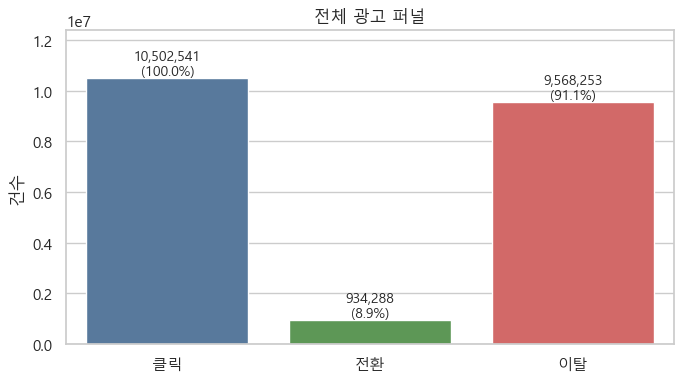

In [15]:
# 클릭 대비 전환/이탈 비율 포함 퍼널 시각화
fig, ax = plt.subplots(figsize=(7, 4))
# 퍼널 단계별 건수 테이블 생성
funnel_plot = pd.DataFrame({'단계': ['클릭', '전환', '이탈'], '건수': [total_click, total_conv, total_churn]})
funnel_plot['클릭 대비 비율(%)'] = safe_div(funnel_plot['건수'], total_click, 100).round(1)
sns.barplot(data=funnel_plot, x='단계', y='건수', hue='단계', palette=['#4C78A8', '#54A24B', '#E45756'], legend=False, ax=ax)
for patch, (_, row) in zip(ax.patches, funnel_plot.iterrows()):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height(),
        f"{row['건수']:,.0f}\n({row['클릭 대비 비율(%)']:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=10
    )
ax.margins(y=0.18)
ax.set_title('전체 광고 퍼널')
ax.set_xlabel('')
ax.set_ylabel('건수')
plt.tight_layout()
plt.show()


## 4. 도메인 x 광고유형

도메인별 전환 기여와 예산 소화 구조 확인
전략 중요도 산정용 기본 테이블


In [16]:
# 목적: 도메인-유형별 클릭/전환/비용 성과 비교
# 기준 데이터: 통합 광고 성과(total_df), 광고적립(df_reward), 광고목록(df_master)
# 전환 로그에 광고 속성 연결
conversion_df = df_reward.merge(ad_info, on='ads_idx', how='left')

# 도메인-유형별 클릭 합계
click_type = (
    total_df.groupby(['domain_name', 'type_name'], as_index=False)
    .agg(click_count=('click_count', 'sum'))
)
# 도메인-유형별 전환-비용 합계
conv_type = (
    conversion_df.groupby(['domain_name', 'type_name'], as_index=False)
    .agg(
        conversion_count=('click_key', 'count'),
        total_spent=('adv_cost', 'sum'),
        ad_count=('ads_idx', 'nunique')
    )
)

# 클릭-전환 합계 테이블
combo = conv_type.merge(click_type, on=['domain_name', 'type_name'], how='left')
combo['click_count'] = combo['click_count'].fillna(0)
# CPA-CVR-광고당 전환 비교
combo['cpconv'] = safe_div(combo['total_spent'], combo['conversion_count']).fillna(0)
combo['cvr'] = safe_div(combo['conversion_count'], combo['click_count'], 100).fillna(0)
combo['conv_per_ad'] = safe_div(combo['conversion_count'], combo['ad_count']).fillna(0)
# 도메인 내부 전환/예산 점유율 계산
combo['conversion_share'] = combo.groupby('domain_name')['conversion_count'].transform(lambda x: safe_div(x, x.sum(), 100))
combo['budget_share'] = combo.groupby('domain_name')['total_spent'].transform(lambda x: safe_div(x, x.sum(), 100))



In [17]:
# 목적: 도메인-유형별 성과 미리보기
# 기준 데이터: 도메인-유형별 성과(combo)
# 결과 확인
display(
    combo.sort_values(['domain_name', 'conversion_count'], ascending=[True, False])
    [['domain_name', 'type_name', 'conversion_count', 'click_count', 'conversion_share', 'budget_share', 'cvr', 'cpconv', 'conv_per_ad']]
    .head(30)
)


,domain_name,type_name,conversion_count,click_count,conversion_share,budget_share,cvr,cpconv,conv_per_ad
1,금융,실행형,43553,"315,881.00",89.72,62.22,13.79,254.95,"6,221.86"
3,금융,참여형,3157,"47,268.00",6.50,35.86,6.68,"2,027.09",78.92
0,금융,설치형,1532,"12,895.00",3.16,1.58,11.88,184.26,383.00
2,금융,유튜브,300,731.00,0.62,0.34,41.04,200.00,300.00
6,기타,참여형,3172,"1,677,580.00",31.92,33.04,0.19,223.39,16.61
5,기타,실행형,2791,"10,440.00",28.09,29.93,26.73,230.00,398.71
4,기타,설치형,2773,"4,045.00",27.91,22.63,68.55,175.05,346.62
7,기타,페이스북,1201,"4,196.00",12.09,14.39,28.62,257.00,"1,201.00"
9,라이프,실행형,35181,"119,107.00",67.57,47.55,29.54,219.89,"4,397.62"
8,라이프,설치형,10962,"18,892.00",21.06,11.71,58.02,173.81,"1,370.25"


### 전환 비중

광고유형별·도메인별 전환 기여 비중 비교


,type_name,conversion_share(%),conversion_count,cpconv,conv_per_ad
3,실행형,48.81,454338,272.31,"11,649.69"
2,설치형,41.50,386282,168.79,"6,035.66"
6,참여형,5.16,47994,682.28,33.01
1,네이버,2.08,19366,230.00,"9,683.00"
5,인스타그램,1.29,11989,227.51,"2,997.25"
0,CPS(구매),0.56,5198,"43,285.63",74.26
7,클릭형,0.38,3570,10.33,"1,190.00"
8,페이스북,0.13,1201,257.00,"1,201.00"


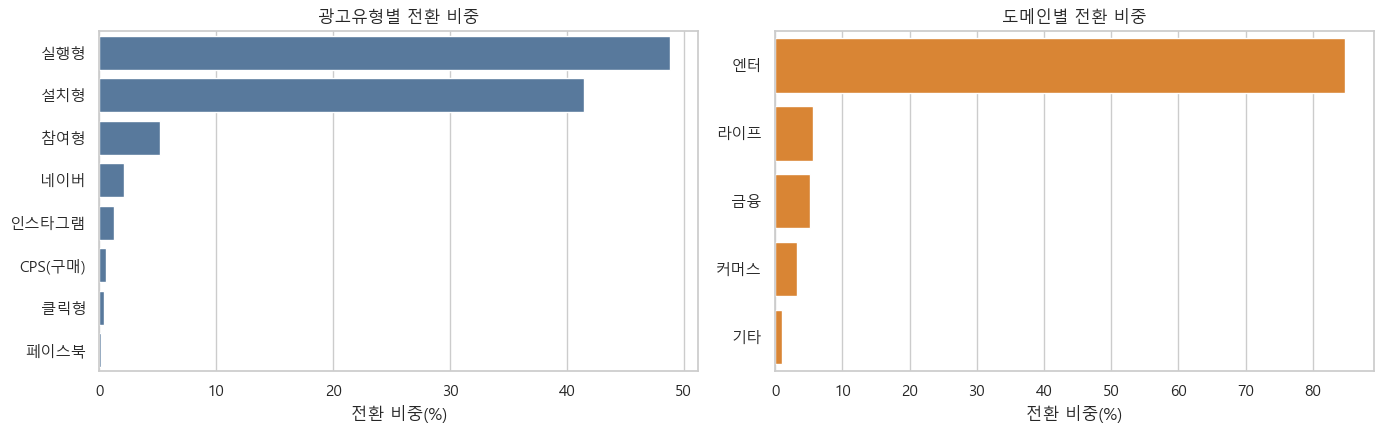

In [18]:
# 전체 전환의 광고유형/도메인 점유율 확인
type_share_plot = (
    combo.groupby('type_name', as_index=False)
    .agg(
        conversion_count=('conversion_count', 'sum'),
        total_spent=('total_spent', 'sum'),
        ad_count=('ad_count', 'sum')
    )
    .sort_values('conversion_count', ascending=False)
)
type_share_plot['conversion_share(%)'] = safe_div(type_share_plot['conversion_count'], type_share_plot['conversion_count'].sum(), 100)
type_share_plot['cpconv'] = safe_div(type_share_plot['total_spent'], type_share_plot['conversion_count']).fillna(0)
type_share_plot['conv_per_ad'] = safe_div(type_share_plot['conversion_count'], type_share_plot['ad_count']).fillna(0)

display(type_share_plot[['type_name', 'conversion_share(%)', 'conversion_count', 'cpconv', 'conv_per_ad']].head(8))

domain_share_plot = combo.groupby('domain_name', as_index=False).agg(conversion_count=('conversion_count', 'sum')).sort_values('conversion_count', ascending=False)
domain_share_plot['conversion_share(%)'] = safe_div(domain_share_plot['conversion_count'], domain_share_plot['conversion_count'].sum(), 100)

# 광고유형/도메인 전환 점유율 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=type_share_plot.head(8), x='conversion_share(%)', y='type_name', color='#4C78A8', ax=axes[0])
axes[0].set_title('광고유형별 전환 비중')
axes[0].set_xlabel('전환 비중(%)')
axes[0].set_ylabel('')

sns.barplot(data=domain_share_plot, x='conversion_share(%)', y='domain_name', color='#F58518', ax=axes[1])
axes[1].set_title('도메인별 전환 비중')
axes[1].set_xlabel('전환 비중(%)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


### 성과 히트맵

전환 기여 비중 기준 도메인별 운영 중심 유형 확인


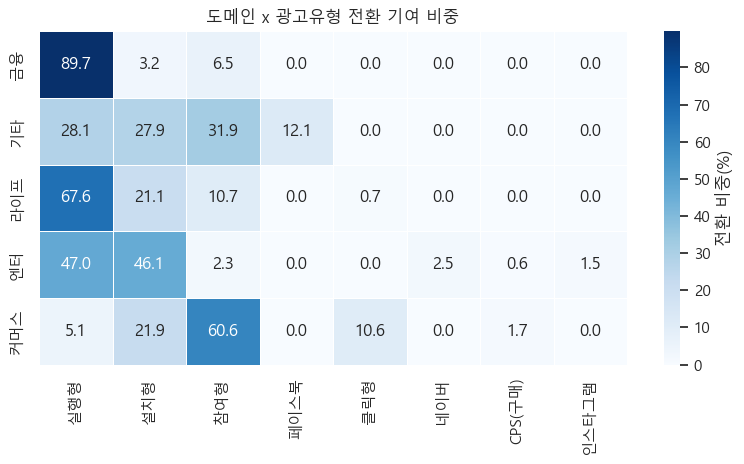

In [19]:
# 목적: 도메인별 광고유형 전환 기여도 히트맵 생성
# 기준 데이터: 전환 분석 데이터(conversion_df)
# 도메인별 유형 전환 점유율 행렬
conv_heat = combo.pivot_table(index='domain_name', columns='type_name', values='conversion_share', aggfunc='sum').fillna(0)

# 전환 규모 작은 유형 제외
heat_cols = conv_heat.sum().sort_values(ascending=False).head(8).index
conv_heat = conv_heat.reindex(columns=heat_cols).fillna(0)

# 히트맵 시각화
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.heatmap(conv_heat, annot=True, fmt='.1f', cmap='Blues', linewidths=.5, cbar_kws={'label': '전환 비중(%)'}, ax=ax)
ax.set_title('도메인 x 광고유형 전환 기여 비중')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


## 5. 예산 규모별 운영 패턴

광고별 실제 집행비 기준 예산구간 분리
도메인별 대표 예산구간·광고유형 조합 확인


In [20]:
## 5. 예산 규모별 운영 패턴

# 광고별 총 집행비 구간 분류
def spend_band(total_spent):
    if total_spent <= 100_000:
        return '소규모(~10만)'
    if total_spent <= 500_000:
        return '중규모(10~50만)'
    if total_spent <= 2_000_000:
        return '대규모(50~200만)'
    return '초대형(200만+)'


# 필요한 컬럼만 사용해서 메모리 절약
spend_base = total_df[
    ['ads_idx', 'domain_name', 'type_name', 'conversion_count', 'total_cost']
].copy()

spend_base['spend_band'] = spend_base['total_cost'].apply(spend_band)

domain_spend_eff = (
    spend_base[spend_base['conversion_count'] > 0]
    .groupby(['domain_name', 'spend_band', 'type_name'], as_index=False)
    .agg(
        conversion_count=('conversion_count', 'sum'),
        total_spent=('total_cost', 'sum'),
        ad_count=('ads_idx', 'nunique')
    )
)

domain_spend_eff['cpa'] = safe_div(
    domain_spend_eff['total_spent'],
    domain_spend_eff['conversion_count']
).fillna(0)

domain_spend_eff['avg_conv_per_ad'] = safe_div(
    domain_spend_eff['conversion_count'],
    domain_spend_eff['ad_count']
).fillna(0)

domain_spend_top = (
    domain_spend_eff
    .sort_values(['domain_name', 'conversion_count', 'cpa'], ascending=[True, False, True])
    .groupby('domain_name', as_index=False)
    .head(1)
)

domain_spend_top[['cpa', 'avg_conv_per_ad']] = (
    domain_spend_top[['cpa', 'avg_conv_per_ad']].round(2)
)

display(domain_spend_top[
    ['domain_name', 'spend_band', 'type_name', 'conversion_count', 'cpa', 'avg_conv_per_ad']
])

,domain_name,spend_band,type_name,conversion_count,cpa,avg_conv_per_ad
9,금융,초대형(200만+),실행형,"31,123.00",260.00,"31,123.00"
14,기타,중규모(10~50만),설치형,"2,204.00",176.86,"1,102.00"
18,라이프,대규모(50~200만),실행형,"23,995.00",215.68,"4,799.00"
46,엔터,초대형(200만+),실행형,"366,921.00",280.00,"61,153.50"
53,커머스,소규모(~10만),참여형,"12,474.00",26.20,24.08


### 운영 타이밍

요일별 최저 CPA와 80% 전환 도달 기간 확인


In [21]:
## 6. 운영 타이밍

# 클릭 로그를 먼저 광고-요일 단위로 축소
eng_small = df_engagement[['ads_idx', 'weekday']]

eng_by_ad_day = (
    eng_small
    .groupby(['ads_idx', 'weekday'], as_index=False)
    .size()
    .rename(columns={'size': 'click_count'})
)

# 축소된 결과에만 도메인 매핑
weekday_click = (
    eng_by_ad_day
    .merge(ad_info[['ads_idx', 'domain_name']], on='ads_idx', how='left')
    .groupby(['domain_name', 'weekday'], as_index=False)['click_count']
    .sum()
)

# 요일별 주요 광고유형
weekday_type = (
    conversion_df
    .groupby(['domain_name', 'weekday', 'type_name'], as_index=False)
    .agg(type_conversion_count=('click_key', 'count'))
    .sort_values(['domain_name', 'weekday', 'type_conversion_count'], ascending=[True, True, False])
    .groupby(['domain_name', 'weekday'], as_index=False)
    .head(1)
    .rename(columns={'type_name': 'main_type'})
)

# 요일별 효율
weekday = (
    conversion_df
    .groupby(['domain_name', 'weekday'], as_index=False)
    .agg(
        conversion_count=('click_key', 'count'),
        total_spent=('adv_cost', 'sum')
    )
    .merge(weekday_click, on=['domain_name', 'weekday'], how='left')
    .merge(
        weekday_type[['domain_name', 'weekday', 'main_type']],
        on=['domain_name', 'weekday'],
        how='left'
    )
)

weekday['click_count'] = weekday['click_count'].fillna(0)

weekday['cpconv'] = safe_div(
    weekday['total_spent'],
    weekday['conversion_count']
).fillna(0)

weekday['cvr'] = safe_div(
    weekday['conversion_count'],
    weekday['click_count'],
    100
).fillna(0)

# 전환 100건 이상 요일 중 CPA 최저 요일 선택
weekday_best = (
    weekday[weekday['conversion_count'] >= 100]
    .sort_values(['domain_name', 'cpconv', 'conversion_count'], ascending=[True, True, False])
    .groupby('domain_name', as_index=False)
    .head(1)
)

weekday_best[['cvr', 'cpconv']] = weekday_best[['cvr', 'cpconv']].round(2)

display(weekday_best[
    ['domain_name', 'weekday', 'conversion_count', 'cvr', 'cpconv', 'main_type']
])

,domain_name,weekday,conversion_count,cvr,cpconv,main_type
0,금융,금,8569,20.57,319.80,실행형
12,기타,토,1393,0.44,207.81,참여형
17,라이프,월,9265,26.34,216.32,실행형
23,엔터,수,141794,20.22,266.34,실행형
30,커머스,수,5352,33.70,715.26,참여형


In [22]:
## 7. 80% 전환 도달 기간

life = conversion_df.dropna(subset=['click_date']).copy()

life['start_date'] = life.groupby('ads_idx')['click_date'].transform('min')
life['day_from_start'] = (
    life['click_date'].dt.normalize() -
    life['start_date'].dt.normalize()
).dt.days + 1

life_daily = (
    life
    .groupby(['domain_name', 'day_from_start'], as_index=False)
    .agg(conversion_count=('click_key', 'count'))
    .sort_values(['domain_name', 'day_from_start'])
)

life_daily['cum_conv'] = life_daily.groupby('domain_name')['conversion_count'].cumsum()
life_daily['total_conv'] = life_daily.groupby('domain_name')['conversion_count'].transform('sum')
life_daily['cum_share'] = safe_div(
    life_daily['cum_conv'],
    life_daily['total_conv'],
    100
)

p80 = (
    life_daily[life_daily['cum_share'] >= 80]
    .sort_values(['domain_name', 'day_from_start'])
    .groupby('domain_name', as_index=False)
    .head(1)
    .rename(columns={
        'day_from_start': 'p80_conversion_day',
        'total_conv': 'total_conversion_count'
    })
)

p80['cum_share'] = p80['cum_share'].round(1)

display(p80[
    ['domain_name', 'p80_conversion_day', 'total_conversion_count', 'cum_share']
])

,domain_name,p80_conversion_day,total_conversion_count,cum_share
18,금융,19,48542,83.90
48,기타,18,9937,82.00
87,라이프,27,52063,80.60
101,엔터,10,790038,81.50
134,커머스,12,30176,81.00


### 도메인 운영

엔터 초대형·설치형 중심, 라이프 초대형·실행형 중심
금융 대규모·설치형, 커머스 소규모 클릭형·참여형 확인


## 7. 통계 검증

도메인별·광고유형별 전환 구조 차이가 전략 점수화의 근거가 될 수 있는지 확인


In [23]:
# 목적: 도메인/광고유형 전환 분포 차이 검정
# 기준 데이터: 전환 분석 데이터(conversion_df)

conversion_table = pd.crosstab(conversion_df['domain_name'], conversion_df['type_name'])
chi2, p_value, dof, expected = chi2_contingency(conversion_table)
cramers_v = np.sqrt(chi2 / (conversion_table.to_numpy().sum() * (min(conversion_table.shape) - 1)))


In [24]:
# 목적: 커머스 내부 광고유형별 전환 구조 검정
# 기준 데이터: 통합 광고 성과(total_df)

commerce_ads = total_df[total_df['domain_name'].eq('커머스')].copy()
commerce_cvr = (
    commerce_ads.groupby('type_name', as_index=False)
    .agg(click_count=('click_count', 'sum'), conversion_count=('conversion_count', 'sum'))
)
commerce_cvr = commerce_cvr[commerce_cvr['click_count'] > 0]
commerce_cvr['non_conversion_count'] = commerce_cvr['click_count'] - commerce_cvr['conversion_count']
commerce_cvr['cvr(%)'] = safe_div(commerce_cvr['conversion_count'], commerce_cvr['click_count'], 100).round(2)
commerce_cvr = commerce_cvr.sort_values('conversion_count', ascending=False)

commerce_table = commerce_cvr.set_index('type_name')[['conversion_count', 'non_conversion_count']]
commerce_chi2, commerce_p, commerce_dof, commerce_expected = chi2_contingency(commerce_table)
commerce_cramers_v = np.sqrt(commerce_chi2 / (commerce_table.to_numpy().sum() * (min(commerce_table.shape) - 1)))


In [25]:
# 목적: 도메인별 전환이 특정 광고유형에 유의하게 치우치는지 확인

domain_type_test_result = pd.DataFrame([{
    '검정': '도메인 × 광고유형 전환 분포',
    'chi-square': round(chi2, 1),
    'dof': int(dof),
    'p-value': f'{p_value:.3e}',
    "Cramer's V": round(cramers_v, 3)
}])


In [26]:
# 도메인/광고유형 전환 분포 검정 결과
display(domain_type_test_result)


,검정,chi-square,dof,p-value,Cramer's V
0,도메인 × 광고유형 전환 분포,"478,655.60",32,0.000e+00,0.36


In [27]:
# 목적: 커머스 도메인 안에서 광고유형별 전환/미전환 구조 차이가 유의한지 확인

commerce_type_test_result = pd.DataFrame([{
    '검정': '커머스 내부 광고유형별 전환 구조',
    'chi-square': round(commerce_chi2, 1),
    'dof': int(commerce_dof),
    'p-value': f'{commerce_p:.3e}',
    "Cramer's V": round(commerce_cramers_v, 3)
}])


In [28]:
# 커머스 내부 광고유형별 전환 구조 검정 결과
display(commerce_type_test_result)


,검정,chi-square,dof,p-value,Cramer's V
0,커머스 내부 광고유형별 전환 구조,"13,745.60",4,0.000e+00,0.35


## 8. 전략 점수 로직


In [29]:
# 도메인별 추천 광고유형 Top3를 만든다.
strategy_view = combo.copy()
strategy_view['score'] = np.sqrt(strategy_view['conversion_share'] * strategy_view['budget_share'])
strategy_view['rank'] = (
    strategy_view.sort_values(['domain_name', 'score', 'conversion_count'], ascending=[True, False, False])
    .groupby('domain_name')
    .cumcount() + 1
)

strategy_view = (
    strategy_view[strategy_view['rank'] <= 3]
    .sort_values(['domain_name', 'rank'])
    [['domain_name', 'rank', 'type_name', 'conversion_share', 'budget_share',
      'conversion_count', 'cvr', 'conv_per_ad', 'score']]
    .copy()
)
strategy_view[['conversion_share', 'budget_share', 'cvr', 'conv_per_ad', 'score']] = (
    strategy_view[['conversion_share', 'budget_share', 'cvr', 'conv_per_ad', 'score']].round(2)
)


In [30]:
# 도메인별 추천 광고유형 Top3를 확인
display(strategy_view)


,domain_name,rank,type_name,conversion_share,budget_share,conversion_count,cvr,conv_per_ad,score
1,금융,1,실행형,89.72,62.22,43553,13.79,"6,221.86",74.72
3,금융,2,참여형,6.50,35.86,3157,6.68,78.92,15.27
0,금융,3,설치형,3.16,1.58,1532,11.88,383.00,2.23
6,기타,1,참여형,31.92,33.04,3172,0.19,16.61,32.48
5,기타,2,실행형,28.09,29.93,2791,26.73,398.71,28.99
4,기타,3,설치형,27.91,22.63,2773,68.55,346.62,25.13
9,라이프,1,실행형,67.57,47.55,35181,29.54,"4,397.62",56.68
10,라이프,2,참여형,10.66,40.72,5549,7.87,10.14,20.83
8,라이프,3,설치형,21.06,11.71,10962,58.02,"1,370.25",15.70
15,엔터,1,실행형,46.99,30.45,371263,49.86,"30,938.58",37.83


## 9. 운영 리스크 유형


In [31]:
# 운영 리스크 유형의 기준: 미전환 클릭 손실이 가장 큰 광고유형
caution_base = total_df[(total_df['click_count'] > 0) & (total_df['conversion_count'] == 0)].copy()

caution_type = (
    caution_base.groupby(['domain_name', 'type_name'], as_index=False)
    .agg(caution_ad_count=('ads_idx', 'nunique'), lost_click=('click_count', 'sum'))
    .sort_values(['domain_name', 'lost_click', 'caution_ad_count'], ascending=[True, False, False])
    .groupby('domain_name', as_index=False)
    .head(1)
    .rename(columns={'type_name': 'caution_type'})
    [['domain_name', 'caution_type', 'caution_ad_count', 'lost_click']]
    .sort_values('domain_name')
    .reset_index(drop=True)
)
caution_type[['caution_ad_count', 'lost_click']] = caution_type[['caution_ad_count', 'lost_click']].astype(int)



In [32]:
# 도메인별 운영 리스크 유형 확인
display(caution_type)


,domain_name,caution_type,caution_ad_count,lost_click
0,금융,참여형,50,6223
1,기타,참여형,181,1631310
2,라이프,참여형,848,3585
3,엔터,참여형,172,1581439
4,커머스,CPS(구매),335,2002


## 10. 대표 우수 광고 사례


In [33]:
# 1순위 추천 유형 안에서 전환 성과가 가장 좋은 광고 선별
recommended_type = (
    strategy_view[strategy_view['rank'] == 1]
    .rename(columns={'type_name': 'recommended_type'})
    [['domain_name', 'recommended_type']]
)

success_case = (
    total_df.merge(
        recommended_type,
        left_on=['domain_name', 'type_name'],
        right_on=['domain_name', 'recommended_type'],
        how='inner'
    )
    .query('conversion_count > 0')
    .sort_values(['domain_name', 'conversion_count', 'cvr'], ascending=[True, False, False])
    .groupby('domain_name', as_index=False)
    .head(1)
    .rename(columns={'ads_name': 'success_case_ad'})
    [['domain_name', 'recommended_type', 'success_case_ad',
      'conversion_count', 'cvr', 'cpconv', 'operation_days']]
    .copy()
)
success_case[['cvr', 'cpconv']] = success_case[['cvr', 'cpconv']].round(2)


In [34]:
# 추천 유형, 대표 사례, 리스크 유형
case_table = (
    recommended_type
    .merge(success_case, on=['domain_name', 'recommended_type'], how='left')
    .merge(caution_type[['domain_name', 'caution_type', 'lost_click']], on='domain_name', how='left')
    [['domain_name', 'recommended_type', 'success_case_ad', 'conversion_count',
      'cvr', 'cpconv', 'operation_days', 'caution_type', 'lost_click']]
)


In [35]:
# 도메인별 대표 우수 광고 사례 확인
display(case_table)


,domain_name,recommended_type,success_case_ad,conversion_count,cvr,cpconv,operation_days,caution_type,lost_click
0,금융,실행형,[오픈하기] KB차차차,"31,123.00",15.25,260.00,21,참여형,6223
1,기타,참여형,충청남도 페이스북,"1,821.00",20.84,280.00,28,참여형,1631310
2,라이프,실행형,알바천국,"10,788.00",15.52,230.00,31,참여형,3585
3,엔터,실행형,K데몬헌터스,"105,702.00",61.44,280.00,5,참여형,1581439
4,커머스,참여형,쿠팡 출석체크 [재참여가능],"8,648.00",88.91,5.00,29,CPS(구매),2002
